In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
import itertools
import seaborn as sns
from matplotlib.colors import ListedColormap
import io
import matplotlib.patches as mpatches
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests

# Functions for calculating different features

In [2]:
def peaks(m, i, h, t, d, growth_curves):
    peaks_list = []
    max_values_added = []


    for j in range(1, int(m) + 1):
        z = str(i) + str(j)


        if z not in growth_curves:
            continue
        y = growth_curves[z]
        x = growth_curves["Day"]


        peaks_idx, _ = find_peaks(y, height=h, threshold=t, distance=d)


        peaks_pos = (
            x.iloc[peaks_idx].values
            if hasattr(x, "iloc")
            else np.array(x)[peaks_idx]
        )
        peaks_height = (
            y.iloc[peaks_idx].values
            if hasattr(y, "iloc")
            else np.array(y)[peaks_idx]
        )

        data = {
            "number_of_tube": z,
            "position": peaks_pos,
            "height": peaks_height,
            "height_parameter": h,
            "threshold_parameter": t,
            "distance_parameter": d,
        }
        peaks_df = pd.DataFrame(data)
        peaks_list.append(peaks_df)

        y_arr = np.asarray(y)
        x_arr = np.asarray(x)

        max_idx = np.argmax(y_arr)
        max_in_curve = y_arr[max_idx]
        max_position = x_arr[max_idx]

        max_data = {
            "number_of_tube": z,
            "position": max_position,
            "height": max_in_curve,
            "height_parameter": h,
            "threshold_parameter": t,
            "distance_parameter": d,
        }
        max_data_df = pd.DataFrame([max_data])
        max_values_added.append(max_data_df)


    max_values = (
        pd.concat(max_values_added, ignore_index=True)
        if max_values_added
        else pd.DataFrame()
    )
    all_peaks_df_list = peaks_list + max_values_added
    all_peaks = (
        pd.concat(all_peaks_df_list, ignore_index=True)
        if all_peaks_df_list
        else pd.DataFrame()
    )

    if not all_peaks.empty:
        all_peaks["prefix"] = all_peaks["number_of_tube"].str.extract(
            "([A-Za-z]+)"
        )
        all_peaks["num"] = (
            all_peaks["number_of_tube"].str.extract("(\d+)").astype(int)
        )

        all_peaks = (
            all_peaks.sort_values(by=["prefix", "num"])
            .drop(columns=["prefix", "num"])
            .drop_duplicates()
            .reset_index(drop=True)
        )

    return all_peaks, max_values

<>:77: SyntaxWarning: invalid escape sequence '\d'
<>:77: SyntaxWarning: invalid escape sequence '\d'
C:\Users\yaras\AppData\Local\Temp\ipykernel_12612\3941691989.py:77: SyntaxWarning: invalid escape sequence '\d'
  all_peaks["number_of_tube"].str.extract("(\d+)").astype(int)


In [3]:
def count(all_peaks, column_name, m, i, h, t, d): 
    count_list=[]
    for j in range (1, int(m)): 
        z= str(i) +str(j) 

        count=all_peaks[column_name].value_counts().get(z, 0)

        count_data={'number_of_tube':z,'peak_count':count}
        count_df=pd.DataFrame(count_data, index=[0])
        count_list.append(count_df)

    count_peaks=pd.concat(count_list) 
    return count_peaks

In [4]:
def media_type(m, count_peaks):
    media_list=[]
    for j in range(1, int(m)):
        if j%12==0:
            for tube in range(j-11, j+1):
                if j-11 <= tube <= j-9:
                    media= 'PRO99'
                    
                elif j-8 <= tube <= j-6:
                    media='lowN (1:8)'
                    
                elif j-5 <= tube <= j-3:
                    media= 'lowP (1:8)'
                    
                else:
                    media= 'lowP (1:50)'
                media_list.append(media)
                    

    # (index in which you want the column to be, 'name of the column', data)
    count_peaks.insert(1, 'media', media_list)
    return media_list, count_peaks

In [5]:
def add_strain(strains, count_peaks):
    strains_list=strains
    strains_list=np.repeat(strains_list, 12)
    count_peaks.insert(2, 'strain', strains_list)
    return strains_list, count_peaks

In [6]:
def d_value(m, i, max_values):

    max_values = max_values.reset_index(drop=True)
    max_values["max_min_diff"] = max_values["height"].sub(0.15)
    max_values["y_90decline"] = max_values["max_min_diff"].multiply(0.10)

    position_of_90decline_lst = []

    for j in range(1, int(m) + 1):
        z = str(i) + str(j)

        if z not in growth_curves:
            continue

        growth_of_z = growth_curves[["Day", z]]
        max_of_z = max_values.loc[max_values["number_of_tube"] == z].squeeze()

     
        if max_of_z.empty:
            continue

        position = growth_of_z.loc[
            (growth_of_z.Day > max_of_z.position)
            & (growth_of_z[z] <= max_of_z.y_90decline)
        ]["Day"].min()

        data = {"number_of_tube": z, "position_of_90decline": position}
        decline_position_df = pd.DataFrame([data])
        position_of_90decline_lst.append(decline_position_df)


    position_of_90decline = pd.concat(
        position_of_90decline_lst, ignore_index=True
    )


    max_values = max_values.merge(
        position_of_90decline, on="number_of_tube", how="left"
    )

    max_values["D_value"] = (
        max_values["position_of_90decline"] - max_values["position"]
    )

    return position_of_90decline, max_values

In [7]:
plt.rcParams['font.family'] = 'Arial'

# GroupA

In [8]:
growth_curves=pd.read_excel(r'C:\Users\yaras\OneDrive\Desktop\Analysis for paper\Python Code\Growth curves of Group A- for python.xlsx')
growth_curves=growth_curves.drop(growth_curves.index[:2])

In [9]:
growth_curves.head()

,Date,Day,A1,A2,A3,A4,A5,A6,A7,A8,...,A63,A64,A65,A66,A67,A68,A69,A70,A71,A72
2,2022-12-05 15:49:00,0,0.095,0.066,0.11,0.044,0.014,0.052,0.019,0.019,...,0.116,0.028,0.048,0.048,0.071,0.081,0.047,0.076,0.053,0.038
3,2022-12-06 12:21:00,0.855556,0.094,0.156,0.099,0.014,0.042,0.081,0.099,0.071,...,0.094,0.066,0.042,0.052,0.061,0.076,0.075,0.051,0.053,0.047
4,2022-12-07 22:54:00,2.295139,0.217,0.245,0.229,0.038,0.042,0.033,0.075,0.107,...,0.223,0.105,0.062,0.07,0.113,0.112,0.137,0.066,0.042,0.052
5,2022-12-08 15:03:00,2.968056,0.24,0.271,0.313,0.015,0.072,0.052,0.133,0.139,...,0.422,0.119,0.133,0.095,0.165,0.152,0.153,0.028,0.024,0.024
6,2022-12-09 22:05:00,4.261111,0.533,0.68,0.652,0.038,0.076,0.043,0.222,0.273,...,0.612,0.236,0.245,0.237,0.258,0.31,0.28,0.001,0.001,0.001


In [10]:
strains=['MED4', 'MIT9312', 'MIT9313', 'MIT1327', 'MIT0604', 'NATL2A']
i= 'A'
m=73
h=0.15
t=0.05
d= None
column_name='number_of_tube'



all_peaks, max_values= peaks(m, i, h, t, d, growth_curves)
count_peaks= count(all_peaks, column_name, m, i, h, t, d)
media_list=media_type(m, count_peaks)
strains_list=add_strain(strains, count_peaks)
position_of_90decline, max_values=d_value(m,i, max_values)


In [11]:
position_of_90decline.max(), position_of_90decline.min()



(number_of_tube                  A9
 position_of_90decline    40.297917
 dtype: object,
 number_of_tube                  A1
 position_of_90decline    11.311806
 dtype: object)

In [12]:
all_peaks_GA=all_peaks
count_peaks_GA=count_peaks
max_GA=max_values

In [13]:
all_peaks_GA.head()

,number_of_tube,position,height,height_parameter,threshold_parameter,distance_parameter
0,A1,12.9125,6.705,0.15,0.05,None
1,A1,21.877083,2.67,0.15,0.05,None
2,A1,23.781944,2.272,0.15,0.05,None
3,A2,14.018056,6.457,0.15,0.05,None
4,A2,16.813194,5.007,0.15,0.05,None


In [14]:
count_peaks_GA.head()

,number_of_tube,media,strain,peak_count
0,A1,PRO99,MED4,3
0,A2,PRO99,MED4,4
0,A3,PRO99,MED4,4
0,A4,lowN (1:8),MED4,1
0,A5,lowN (1:8),MED4,1


In [15]:
max_GA.head()

,number_of_tube,position,height,height_parameter,threshold_parameter,distance_parameter,max_min_diff,y_90decline,position_of_90decline,D_value
0,A1,12.912500,6.705,0.15,0.05,None,6.555,0.6555,33.060417,20.147917
1,A2,14.018056,6.457,0.15,0.05,None,6.307,0.6307,30.004167,15.986111
2,A3,12.330556,6.291,0.15,0.05,None,6.141,0.6141,28.787500,16.456944
3,A4,18.927778,4.866,0.15,0.05,None,4.716,0.4716,28.787500,9.859722
4,A5,16.813194,4.609,0.15,0.05,None,4.459,0.4459,26.104167,9.290972


# GroupB

In [16]:
growth_curves=pd.read_excel(r'C:\Users\yaras\OneDrive\Desktop\Analysis for paper\Python Code\Growth curves of Group B- for python.xlsx')
growth_curves=growth_curves.drop(growth_curves.index[:2])

In [17]:
growth_curves.head()

,Date,Day,B1,B2,B3,B4,B5,B6,B7,B8,...,B63,B64,B65,B66,B67,B68,B69,B70,B71,B72
2,2022-12-11 14:06:00,0,0.119,0.197,0.194,0.145,0.147,0.173,0.198,0.225,...,0.243,0.273,0.331,0.225,0.212,0.272,0.353,0.305,0.437,0.292
3,2022-12-12 11:52:00,0.906944,0.178,0.236,0.184,0.247,0.18,0.218,0.208,0.186,...,0.351,0.206,0.21,0.166,0.324,0.348,0.352,0.137,0.226,0.201
4,2022-12-13 10:17:00,1.840972,0.336,0.25,0.284,0.308,0.27,0.285,0.249,0.302,...,0.474,0.232,0.256,0.207,0.403,0.356,0.381,0.151,0.085,0.108
5,2022-12-14 22:28:00,3.348611,0.539,0.586,0.509,0.592,0.571,0.584,0.53,0.551,...,0.787,0.41,0.318,0.331,0.656,0.715,0.621,0.052,0.01,-0.042
6,2022-12-15 10:29:00,3.849306,0.777,0.673,0.79,0.815,0.72,0.72,0.805,0.735,...,1.077,0.491,0.493,0.448,0.813,0.856,0.818,0.089,0.014,0.01


In [18]:
strains=['MED4', 'MIT9312', 'MIT9515', 'MIT9215', 'AS9601', 'PAC1']
i= 'B'
m=73
h=0.15
t=0.05
d= None
column_name='number_of_tube'



all_peaks, max_values= peaks(m, i, h, t, d, growth_curves)
count_peaks= count(all_peaks, column_name, m, i, h, t, d)
media_list=media_type(m, count_peaks)
strains_list=add_strain(strains, count_peaks)
position_of_90decline, max_values=d_value(m,i, max_values)


In [19]:
position_of_90decline.max(), position_of_90decline.min()


(number_of_tube                  B9
 position_of_90decline    41.813889
 dtype: object,
 number_of_tube                 B1
 position_of_90decline    3.348611
 dtype: object)

In [20]:
all_peaks_GB=all_peaks
count_peaks_GB=count_peaks
max_GB=max_values

In [21]:
all_peaks_GB.head()

,number_of_tube,position,height,height_parameter,threshold_parameter,distance_parameter
0,B1,10.902083,5.989,0.15,0.05,None
1,B1,15.957639,4.361,0.15,0.05,None
2,B1,22.865972,2.346,0.15,0.05,None
3,B1,27.154167,2.202,0.15,0.05,None
4,B2,10.902083,6.483,0.15,0.05,None


In [22]:
count_peaks_GB.head()

,number_of_tube,media,strain,peak_count
0,B1,PRO99,MED4,4
0,B2,PRO99,MED4,4
0,B3,PRO99,MED4,4
0,B4,lowN (1:8),MED4,2
0,B5,lowN (1:8),MED4,2


In [23]:
max_GB.head()

,number_of_tube,position,height,height_parameter,threshold_parameter,distance_parameter,max_min_diff,y_90decline,position_of_90decline,D_value
0,B1,10.902083,5.989,0.15,0.05,None,5.839,0.5839,35.058333,24.156250
1,B2,10.902083,6.483,0.15,0.05,None,6.333,0.6333,34.379861,23.477778
2,B3,10.902083,6.149,0.15,0.05,None,5.999,0.5999,33.170833,22.268750
3,B4,9.920139,5.346,0.15,0.05,None,5.196,0.5196,21.900000,11.979861
4,B5,9.920139,5.044,0.15,0.05,None,4.894,0.4894,22.865972,12.945833


# GroupC

In [24]:
growth_curves=pd.read_excel(r'C:\Users\yaras\OneDrive\Desktop\Analysis for paper\Python Code\Growth curves of Group C- for python.xlsx')
growth_curves=growth_curves.drop(growth_curves.index[:2])

In [25]:
growth_curves.head()

,Date,Day,C1,C2,C3,C4,C5,C6,C7,C8,...,C39,C40,C41,C42,C43,C44,C45,C46,C47,C48
2,2022-12-19 16:31:00,0,0.172,0.128,0.095,0.1,0.119,0.086,0.167,0.182,...,0.38,0.28,0.165,0.217,0.258,0.409,0.402,0.224,0.227,0.216
3,2022-12-20 11:06:00,0.774306,0.22,0.217,0.205,0.039,0.138,0.038,0.196,0.237,...,0.561,0.442,0.427,0.497,0.59,0.584,0.515,0.164,0.19,0.204
4,2022-12-21 12:21:00,1.826389,0.399,0.427,0.421,0.061,0.081,0.071,0.281,0.316,...,0.836,0.645,0.77,0.684,0.819,0.777,0.772,0.286,0.256,0.274
5,2022-12-22 11:36:00,2.795139,0.648,0.776,0.666,0.043,0.048,0.052,0.506,0.511,...,1.227,0.956,0.934,0.963,1.285,1.276,1.263,0.35,0.319,0.342
6,2022-12-24 14:21:00,4.909722,2.065,2.165,2.06,0.133,0.084,0.099,1.388,1.4,...,2.059,1.966,1.929,1.861,2.716,2.809,2.541,0.628,0.605,0.507


In [26]:
strains=['MED4', 'MIT9312', 'MIT9202', 'SB']
i= 'C'
m=49
h=0.15
t=0.05
d= None
column_name='number_of_tube'



all_peaks, max_values= peaks(m, i, h, t, d, growth_curves)
count_peaks= count(all_peaks, column_name, m, i, h, t, d)
media_list=media_type(m, count_peaks)
strains_list=add_strain(strains, count_peaks)
position_of_90decline, max_values=d_value(m,i, max_values)

In [27]:
position_of_90decline.max(), position_of_90decline.min()


(number_of_tube                  C9
 position_of_90decline    43.880556
 dtype: object,
 number_of_tube                  C1
 position_of_90decline    16.795139
 dtype: object)

In [28]:
all_peaks_GC=all_peaks
count_peaks_GC=count_peaks
max_GC=max_values

In [29]:
all_peaks_GC.head()

,number_of_tube,position,height,height_parameter,threshold_parameter,distance_parameter
0,C1,8.859722,5.768,0.15,0.05,None
1,C1,14.879861,2.976,0.15,0.05,None
2,C1,19.054167,2.71,0.15,0.05,None
3,C2,8.859722,5.839,0.15,0.05,None
4,C2,14.879861,3.643,0.15,0.05,None


In [30]:
count_peaks_GC.head()

,number_of_tube,media,strain,peak_count
0,C1,PRO99,MED4,3
0,C2,PRO99,MED4,5
0,C3,PRO99,MED4,4
0,C4,lowN (1:8),MED4,1
0,C5,lowN (1:8),MED4,1


In [31]:
max_GC.head()

,number_of_tube,position,height,height_parameter,threshold_parameter,distance_parameter,max_min_diff,y_90decline,position_of_90decline,D_value
0,C1,8.859722,5.768,0.15,0.05,None,5.618,0.5618,26.963889,18.104167
1,C2,8.859722,5.839,0.15,0.05,None,5.689,0.5689,26.963889,18.104167
2,C3,8.859722,5.876,0.15,0.05,None,5.726,0.5726,26.279861,17.420139
3,C4,14.879861,4.539,0.15,0.05,None,4.389,0.4389,23.989583,9.109722
4,C5,15.986111,4.691,0.15,0.05,None,4.541,0.4541,25.070833,9.084722


# GroupD

In [32]:
growth_curves=pd.read_excel(r'C:\Users\yaras\OneDrive\Desktop\Analysis for paper\Python Code\Growth curves of Group D- for python.xlsx')
growth_curves=growth_curves.drop(growth_curves.index[:2])

In [33]:
growth_curves.head()

,Date,Day,D1,D2,D3,D4,D5,D6,D7,D8,...,D51,D52,D53,D54,D55,D56,D57,D58,D59,D60
2,2023-01-09 13:30:00,0,0.335,0.334,0.318,0.258,0.309,0.251,0.229,0.295,...,0.433,0.176,0.231,0.262,0.63,0.505,0.463,0.335,0.358,0.314
3,2023-01-10 10:50:00,0.888889,0.531,0.46,0.459,0.273,0.3,0.262,0.397,0.333,...,0.563,0.32,0.316,0.314,0.647,0.676,0.62,0.303,0.336,0.283
4,2023-01-11 11:55:00,1.934028,0.719,0.801,0.715,0.4,0.46,0.397,0.586,0.617,...,1.042,0.462,0.566,0.545,1.116,1.082,1.056,0.415,0.298,0.445
5,2023-01-12 16:26:00,3.122222,1.261,1.255,1.308,0.844,0.917,0.786,1.108,1.012,...,1.92,0.7,0.878,0.768,1.951,1.801,1.716,0.453,0.43,0.472
6,2023-01-13 18:29:00,4.207639,1.784,1.967,1.998,1.353,1.504,1.485,1.731,1.726,...,3.287,1.321,1.655,1.514,3.133,3.03,3.129,0.728,0.726,0.812


In [34]:
strains=['MED4', 'MIT9312', 'MIT9301', 'MIT1314', 'NATL1A']
i= 'D'
m=61
h=0.15
t=0.05
d= None
column_name='number_of_tube'



all_peaks, max_values= peaks(m, i, h, t, d, growth_curves)
count_peaks= count(all_peaks, column_name, m, i, h, t, d)
media_list=media_type(m, count_peaks)
strains_list=add_strain(strains, count_peaks)
position_of_90decline, max_values=d_value(m,i, max_values)

In [35]:
position_of_90decline.max(), position_of_90decline.min()


(number_of_tube                 D9
 position_of_90decline    47.88125
 dtype: object,
 number_of_tube                  D1
 position_of_90decline    12.852778
 dtype: object)

In [36]:
all_peaks_GD=all_peaks
count_peaks_GD=count_peaks
max_GD=max_values

In [37]:
all_peaks_GD.head()

,number_of_tube,position,height,height_parameter,threshold_parameter,distance_parameter
0,D1,8.990972,6.429,0.15,0.05,None
1,D1,10.953472,6.348,0.15,0.05,None
2,D1,19.31875,3.328,0.15,0.05,None
3,D1,22.196528,2.416,0.15,0.05,None
4,D2,8.990972,6.412,0.15,0.05,None


In [38]:
count_peaks_GD.head()

,number_of_tube,media,strain,peak_count
0,D1,PRO99,MED4,4
0,D2,PRO99,MED4,6
0,D3,PRO99,MED4,5
0,D4,lowN (1:8),MED4,1
0,D5,lowN (1:8),MED4,1


In [39]:
max_GD.head()

,number_of_tube,position,height,height_parameter,threshold_parameter,distance_parameter,max_min_diff,y_90decline,position_of_90decline,D_value
0,D1,8.990972,6.429,0.15,0.05,None,6.279,0.6279,35.143750,26.152778
1,D2,8.990972,6.412,0.15,0.05,None,6.262,0.6262,31.955556,22.964583
2,D3,8.990972,6.472,0.15,0.05,None,6.322,0.6322,31.955556,22.964583
3,D4,8.990972,5.643,0.15,0.05,None,5.493,0.5493,19.318750,10.327778
4,D5,8.990972,5.701,0.15,0.05,None,5.551,0.5551,17.972917,8.981944


# Concat data from all groups

In [40]:
all_peaks_dfs=[all_peaks_GA, all_peaks_GB, all_peaks_GC, all_peaks_GD]
count_peaks_dfs=[count_peaks_GA, count_peaks_GB, count_peaks_GC, count_peaks_GD]
all_max_dfs=[max_GA, max_GB, max_GC, max_GD]
peaks_allexp=pd.concat(all_peaks_dfs, ignore_index=True)
count_peaks_allexp=pd.concat(count_peaks_dfs, ignore_index=True)
max_allexp=pd.concat(all_max_dfs, ignore_index=True)

In [41]:
max_allexp['position_of_90decline'].max(), max_allexp['position_of_90decline'].min()


(np.float64(47.881249999998545), np.float64(3.3486111111124046))

In [42]:
pattern=(1, 2, 3)*84
count_peaks_allexp.insert(0, 'replicate', pattern)
count_peaks_allexp

,replicate,number_of_tube,media,strain,peak_count
0,1,A1,PRO99,MED4,3
1,2,A2,PRO99,MED4,4
2,3,A3,PRO99,MED4,4
3,1,A4,lowN (1:8),MED4,1
4,2,A5,lowN (1:8),MED4,1
...,...,...,...,...,...
247,2,D56,lowP (1:8),NATL1A,2
248,3,D57,lowP (1:8),NATL1A,2
249,1,D58,lowP (1:50),NATL1A,3
250,2,D59,lowP (1:50),NATL1A,1


In [43]:
with pd.ExcelWriter('Peaks_with_count_allgroups.xlsx') as writer:
    peaks_allexp.to_excel(writer, sheet_name='peaks_allgroups', index=False)   
    count_peaks_allexp.to_excel(writer, sheet_name='count_allgroups', index=False)  
    max_allexp.to_excel(writer, sheet_name='max_summary_allexp', index=False)  

# Features and traits of each strain

In [44]:
count_peaks=pd.read_excel(r'C:\Users\yaras\OneDrive\Desktop\Analysis for paper\Analysis- home\Maxima and minima\Peaks with count_allgroups.xlsx', sheet_name='count_allgroups')
max_allexp=pd.read_excel(r'C:\Users\yaras\OneDrive\Desktop\Analysis for paper\Analysis- home\Maxima and minima\Peaks with count_allgroups.xlsx', sheet_name='max_summary_allexp')



In [45]:
traits_allgroups=pd.DataFrame()
traits_allgroups['replicate']=count_peaks['replicate']
traits_allgroups['number_of_tube']=count_peaks['number_of_tube']
traits_allgroups['media']=count_peaks['media']
traits_allgroups['strain']=count_peaks['strain']
traits_allgroups['peak_count']=count_peaks['peak_count']
traits_allgroups['max_FL']=max_allexp['height']
traits_allgroups['max_day']=max_allexp['position']
traits_allgroups['D_value']=max_allexp['D_value']


data = """
MED4 HLI HL Mediterranean 5
MIT9312 HLII HL Gulf_Stream 135
MIT9313 LLIV LL Gulf_Stream 135
MIT1327 LLIV LL Station_ALOHA 150
MIT0604 HLII HL Station_ALOHA 175
NATL2A LLI LL North_Atlantic 10
MIT9515 HLI HL Tropical_Pacific 15
MIT9215 HLII HL Equatorial_Pacific Surface
AS9601 HLII HL Arabian_Sea 50
PAC1 LLI LL Station_ALOHA 100
MIT9202 HLII HL Tropical_Pacific 79
SB HLII HL Western_Pacific 40
MIT9301 HLII HL Sargasso_Sea 90
MIT1314 HLII HL Station_ALOHA 150
NATL1A LLI LL North_Atlantic 30
"""


meta_df = pd.read_csv(
    io.StringIO(data.strip()),
    sep=r"\s+",
    names=["strain", "clade", "ecotype", "location", "depth"],
).drop_duplicates("strain")


traits_allgroups = traits_allgroups.merge(meta_df, on="strain", how="left")



In [46]:
traits_allgroups

,replicate,number_of_tube,media,strain,peak_count,max_FL,max_day,D_value,clade,ecotype,location,depth
0,1,A1,PRO99,MED4,3,6.705,12.912500,20.147917,HLI,HL,Mediterranean,5
1,2,A2,PRO99,MED4,4,6.457,14.018056,15.986111,HLI,HL,Mediterranean,5
2,3,A3,PRO99,MED4,4,6.291,12.330556,16.456944,HLI,HL,Mediterranean,5
3,1,A4,lowN (1:8),MED4,1,4.866,18.927778,9.859722,HLI,HL,Mediterranean,5
4,2,A5,lowN (1:8),MED4,1,4.609,16.813194,9.290972,HLI,HL,Mediterranean,5
...,...,...,...,...,...,...,...,...,...,...,...,...
247,2,D56,lowP (1:8),NATL1A,2,8.143,6.988194,9.915972,LLI,LL,North_Atlantic,30
248,3,D57,lowP (1:8),NATL1A,2,7.740,6.988194,10.984722,LLI,LL,North_Atlantic,30
249,1,D58,lowP (1:50),NATL1A,3,1.250,6.988194,12.330556,LLI,LL,North_Atlantic,30
250,2,D59,lowP (1:50),NATL1A,1,1.128,6.988194,12.330556,LLI,LL,North_Atlantic,30


In [47]:
max_list=traits_allgroups['max_FL'].tolist()
average_lst=[]
norm_lst=[]
for i in range (len(max_list)+1):
    if i%12==0 and i>0:
        average=(max_list[i-12]+max_list[i-11]+max_list[i-10])/3
        average_lst.append(average)

mean_lst=np.repeat(average_lst, 12)

for j in range (len(max_list)):
    norm=((max_list[j])/(mean_lst[j]))*100 
    norm_lst.append(norm)
    
traits_allgroups['norm_toPRO99']=norm_lst
    


In [48]:
traits_allgroups

,replicate,number_of_tube,media,strain,peak_count,max_FL,max_day,D_value,clade,ecotype,location,depth,norm_toPRO99
0,1,A1,PRO99,MED4,3,6.705,12.912500,20.147917,HLI,HL,Mediterranean,5,103.403074
1,2,A2,PRO99,MED4,4,6.457,14.018056,15.986111,HLI,HL,Mediterranean,5,99.578471
2,3,A3,PRO99,MED4,4,6.291,12.330556,16.456944,HLI,HL,Mediterranean,5,97.018455
3,1,A4,lowN (1:8),MED4,1,4.866,18.927778,9.859722,HLI,HL,Mediterranean,5,75.042410
4,2,A5,lowN (1:8),MED4,1,4.609,16.813194,9.290972,HLI,HL,Mediterranean,5,71.079011
...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,2,D56,lowP (1:8),NATL1A,2,8.143,6.988194,9.915972,LLI,LL,North_Atlantic,30,98.432589
248,3,D57,lowP (1:8),NATL1A,2,7.740,6.988194,10.984722,LLI,LL,North_Atlantic,30,93.561125
249,1,D58,lowP (1:50),NATL1A,3,1.250,6.988194,12.330556,LLI,LL,North_Atlantic,30,15.110001
250,2,D59,lowP (1:50),NATL1A,1,1.128,6.988194,12.330556,LLI,LL,North_Atlantic,30,13.635265


## Note that growth rates were calculated in a seperate notebook titled "growth rates"

In [49]:
growth_rate = [
    0.377, 0.394, 0.391, 0.395, 0.393, 0.385, 0.386, 0.380, 0.371, 0.402, 0.402, 0.385, 0.464, 0.501, 0.514, 0.507, 0.443, 0.479, 0.443,
    0.493, 0.462, 0.430, 0.393, 0.420, 0.460, 0.407, 0.414, 0.417, 0.434, 0.427, 0.421, 0.450, 0.401, 0.317, 0.466, 0.336, 0.303, 0.273, 0.272, 0.303,
    0.304, 0.288, 0.319, 0.301, 0.325, 0.325, 0.325, 0.332, 0.470, 0.523, 0.470, 0.450, 0.481, 0.461, 0.466, 0.450, 0.457, 0.429, 0.429, 0.429, 0.420,
    0.443, 0.412,
    0.453, 0.444, 0.515, 0.486, 0.486, 0.497, 0.527, 0.442, 0.335, 0.375, 0.385, 0.392, 0.362, 0.395, 0.381, 0.391, 0.384, 0.376, 0.455, 0.377,
    0.407, 0.353, 0.372, 0.380, 0.415, 0.403, 0.429, 0.400, 0.386, 0.387, 0.317, 0.310, 0.332, 0.298, 0.310, 0.310, 0.259, 0.273, 0.262, 0.275,
    0.295, 0.293, 0.312, 0.238, 0.280, 0.279, 0.276, 0.270, 0.219, 0.180, 0.227, 0.235, 0.208, 0.214, 0.239, 0.191, 0.246, 0.394, 0.383, 0.381,
    0.374, 0.406, 0.378, 0.357, 0.371, 0.397, 0.323, 0.305, 0.345, 0.361, 0.365, 0.376, 0.357, 0.360, 0.364, 0.323, 0.352, 0.347, 0.446, 0.000,
    0.000, 0.477, 0.447, 0.455, 0.377, 0.405, 0.407, 0.426, 0.353, 0.354, 0.298, 0.321, 0.352, 0.392, 0.404, 0.406, 0.481, 0.451, 0.488, 0.466,
    0.409, 0.528, 0.426, 0.461, 0.391, 0.434, 0.417, 0.387, 0.411, 0.468, 0.408, 0.364, 0.347, 0.353, 0.260, 0.272, 0.283, 0.193, 0.196, 0.187,
    0.253, 0.239, 0.278, 0.272, 0.391, 0.330, 0.247, 0.222, 0.191, 0.391, 0.396, 0.410, 0.434, 0.419, 0.436, 0.436, 0.431, 0.392, 0.367, 0.369,
    0.352, 0.483, 0.509, 0.465, 0.382, 0.353, 0.347, 0.493, 0.498, 0.477, 0.369, 0.338, 0.267, 0.421, 0.394, 0.399, 0.388, 0.424, 0.441, 0.400,
    0.394, 0.390, 0.428, 0.386, 0.348, 0.434, 0.399, 0.426, 0.393, 0.400, 0.402, 0.489, 0.483, 0.477, 0.303, 0.298, 0.339, 0.440, 0.490, 0.511,
    0.481, 0.486, 0.467, 0.415, 0.433, 0.454, 0.223, 0.209, 0.220
]

traits_allgroups['growth_rate'] = growth_rate

In [50]:
traits_allgroups=traits_allgroups[[ 'replicate', 'number_of_tube', 'media', 'strain', 'clade','ecotype', 'depth', 'location', 'max_FL', 'max_day', 'growth_rate', 'peak_count', 
    'D_value', 'norm_toPRO99']]
 

# Supplementary FS6

In [51]:
traits_allgroups

,replicate,number_of_tube,media,strain,clade,ecotype,depth,location,max_FL,max_day,growth_rate,peak_count,D_value,norm_toPRO99
0,1,A1,PRO99,MED4,HLI,HL,5,Mediterranean,6.705,12.912500,0.377,3,20.147917,103.403074
1,2,A2,PRO99,MED4,HLI,HL,5,Mediterranean,6.457,14.018056,0.394,4,15.986111,99.578471
2,3,A3,PRO99,MED4,HLI,HL,5,Mediterranean,6.291,12.330556,0.391,4,16.456944,97.018455
3,1,A4,lowN (1:8),MED4,HLI,HL,5,Mediterranean,4.866,18.927778,0.395,1,9.859722,75.042410
4,2,A5,lowN (1:8),MED4,HLI,HL,5,Mediterranean,4.609,16.813194,0.393,1,9.290972,71.079011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,2,D56,lowP (1:8),NATL1A,LLI,LL,30,North_Atlantic,8.143,6.988194,0.433,2,9.915972,98.432589
248,3,D57,lowP (1:8),NATL1A,LLI,LL,30,North_Atlantic,7.740,6.988194,0.454,2,10.984722,93.561125
249,1,D58,lowP (1:50),NATL1A,LLI,LL,30,North_Atlantic,1.250,6.988194,0.223,3,12.330556,15.110001
250,2,D59,lowP (1:50),NATL1A,LLI,LL,30,North_Atlantic,1.128,6.988194,0.209,1,12.330556,13.635265


In [52]:
with pd.ExcelWriter('traits_allgroups.xlsx') as writer:
    traits_allgroups.to_excel(writer, sheet_name='traits_allgroups', index=False)   


In [53]:
corr_df=(traits_allgroups.loc[:, 'growth_rate':'norm_toPRO99']).corr().round(2)
corr_df

,growth_rate,peak_count,D_value,norm_toPRO99
growth_rate,1.00,0.05,0.01,0.38
peak_count,0.05,1.00,0.71,0.47
D_value,0.01,0.71,1.00,0.25
norm_toPRO99,0.38,0.47,0.25,1.00


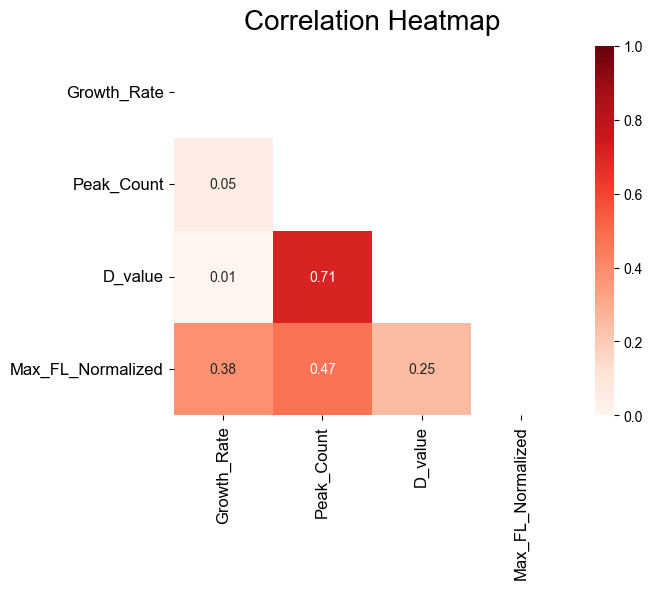

In [54]:

corr_df= corr_df.rename(columns={'growth_rate': 'Growth_Rate', 'peak_count': 'Peak_Count', 'norm_toPRO99':'Max_FL_Normalized'})
corr_df= corr_df.rename(index={'growth_rate': 'Growth_Rate', 'peak_count': 'Peak_Count', 'norm_toPRO99':'Max_FL_Normalized'})


matrix = np.triu(corr_df)


correlation_heatmap=sns.heatmap(corr_df, vmax=1, vmin=0, annot=True,cmap='Reds', mask=matrix)
correlation_heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':20}, pad=12);

plt.tick_params(axis='x', color='black', labelsize='large', rotation=90)
plt.tick_params(axis='y', color='black', labelsize='large', rotation=360)

# Supplementary FS5

In [55]:
"""If you want to use the bonferroni method instaed of the Benjamini/Hochberg, replace fdr_bh with b in method 
(in the pair_test) """

strain_lst= ['MED4', 'MIT9312', 'MIT9313', 'MIT1327', 'MIT0604', 'NATL2A','MIT9515', 'MIT9215', 'AS9601', 'PAC1', 'MIT9202',
             'SB', 'MIT9301', 'MIT1314', 'NATL1A']
variables=['growth_rate', 'peak_count', 'D_value', 'norm_toPRO99',]
OLS_lst=[]
pairt_lst=[]
for v in variables:
    for p in strain_lst:
        mod = ols(f'{v} ~ C(media)',data=traits_allgroups.loc[traits_allgroups['strain']==p]).fit()


        OLS_data=pd.DataFrame({'variable':v, 'strain':p, 'F-statistic':mod.fvalue, 'F-pvalue':mod.f_pvalue, 
                             'Df_Residuals':mod.df_resid,'Df_Model':mod.df_model}, index=[0])
        OLS_lst.append(OLS_data)

        pair_t = mod.t_test_pairwise("C(media)", method='fdr_bh')

        pairt_data=pair_t.result_frame.drop(columns=['coef', 'std err', 't', 'P>|t|', 'Conf. Int. Low', 'Conf. Int. Upp.'] )
        pairt_data.insert(0, 'strain', p)
        pairt_data.insert(0, 'variable', v)
        pairt_lst.append(pairt_data)

OLS_df=pd.concat(OLS_lst)
pairt_df=pd.concat(pairt_lst)
pairt_df

,variable,strain,pvalue-fdr_bh,reject-fdr_bh
lowN (1:8)-PRO99,growth_rate,MED4,0.523530,False
lowP (1:50)-PRO99,growth_rate,MED4,0.082655,False
lowP (1:8)-PRO99,growth_rate,MED4,0.338520,False
lowP (1:50)-lowN (1:8),growth_rate,MED4,0.182986,False
lowP (1:8)-lowN (1:8),growth_rate,MED4,0.523530,False
...,...,...,...,...
lowP (1:50)-PRO99,norm_toPRO99,NATL1A,0.000017,True
lowP (1:8)-PRO99,norm_toPRO99,NATL1A,0.506641,False
lowP (1:50)-lowN (1:8),norm_toPRO99,NATL1A,0.000059,True
lowP (1:8)-lowN (1:8),norm_toPRO99,NATL1A,0.082012,False


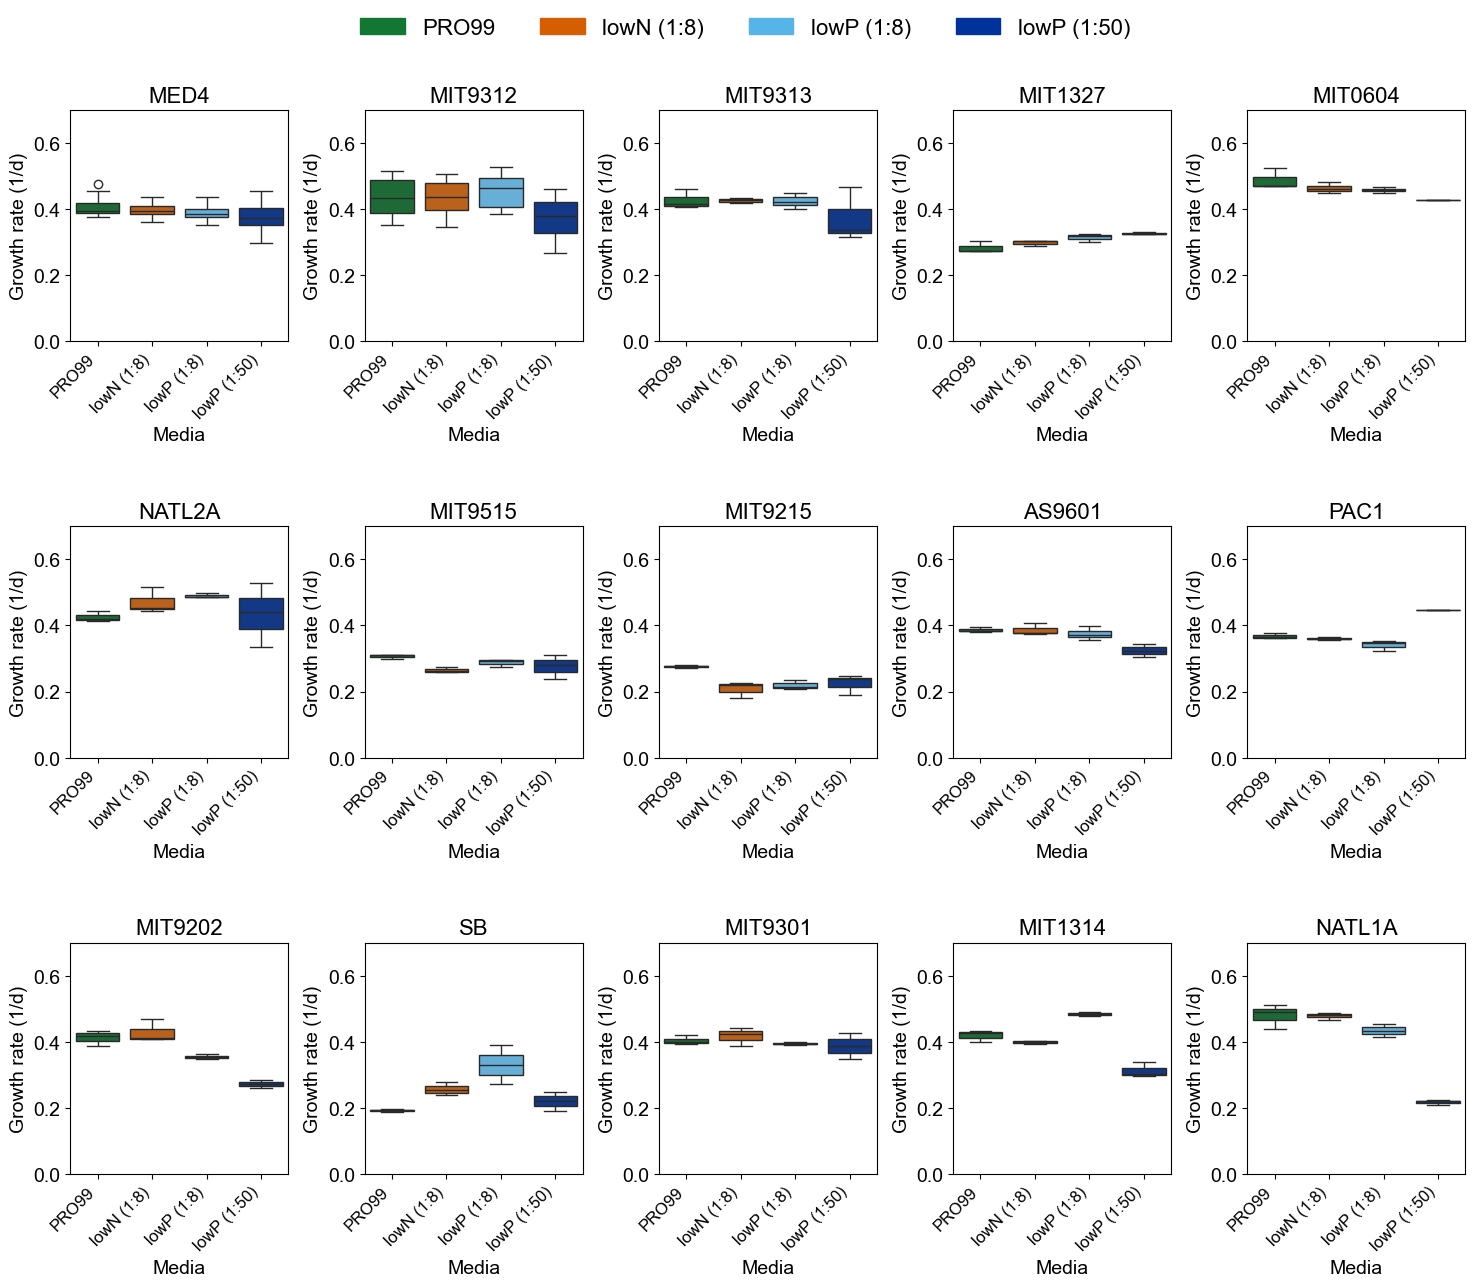

In [56]:
traits_allgroups = traits_allgroups[
    ~(
        (traits_allgroups["strain"] == "PAC1")
        & (traits_allgroups["media"] == "lowP (1:50)")
        & (traits_allgroups["replicate"].astype(str).str.strip().isin(["2", "3"]))
    )
].reset_index(drop=True)

unique_strains = traits_allgroups['strain'].unique()

palette = {'PRO99': '#117733', 'lowN (1:8)': '#D55E00', 'lowP (1:8)': '#56B4E9', 'lowP (1:50)': '#003399'}


fig, axes = plt.subplots(3, 5, figsize=(18, 14), gridspec_kw={'hspace': 0.8, 'wspace': 0.35})

axes = axes.flatten()

for i, strain in enumerate(unique_strains):
    ax = axes[i]
    strain_data = traits_allgroups[traits_allgroups['strain'] == strain]
    sns.boxplot(data=strain_data, x='media', y='growth_rate', ax=ax, hue='media', palette=palette, legend=False)
    
    ax.set_title(f'{strain}', fontsize=16)
    

    ax.set_ylabel('Growth rate (1/d)', fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_ylim(0, 0.7)
  

    ax.set_xlabel('Media', fontsize=14)
    ax.tick_params(axis='x', bottom=True, labelsize=12)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')


legend_patches = [mpatches.Patch(color=color, label=label) for label, color in palette.items()]
fig.legend(handles=legend_patches, loc="upper center", bbox_to_anchor=(0.5, 0.96), ncol=4, frameon=False, fontsize=16)

plt.subplots_adjust(top=0.88, bottom=0.12)

plt.show()

# Figure 3A

In [57]:
media_lst = traits_allgroups['media'].dropna().unique().tolist()
variables = ['growth_rate', 'peak_count', 'D_value', 'norm_toPRO99']

OLS_lst = []

for v in variables:
    for m in media_lst:
        media_data = traits_allgroups.loc[traits_allgroups['media'] == m]
        
        # Skip if insufficient data or fewer than 2 ecotypes
        if len(media_data) < 3 or len(media_data['ecotype'].dropna().unique()) < 2:
            continue
            
        # Fit OLS model comparing ecotypes (HL vs LL) within this media
        mod = ols(f'{v} ~ C(ecotype)', data=media_data).fit()

        OLS_lst.append({
            'variable': v,
            'media': m,
            'F-statistic': mod.fvalue,
            'F-pvalue': mod.f_pvalue,
            'Df_Residuals': mod.df_resid,
            'Df_Model': mod.df_model
        })


OLS_df = pd.DataFrame(OLS_lst)


reject, pvals_corrected, _, _ = multipletests(OLS_df['F-pvalue'], alpha=0.05, method='fdr_bh')


OLS_df['pvalue_fdr_bh'] = pvals_corrected
OLS_df['reject_fdr_bh'] = reject

OLS_df

,variable,media,F-statistic,F-pvalue,Df_Residuals,Df_Model,pvalue_fdr_bh,reject_fdr_bh
0,growth_rate,PRO99,0.049741,8.242596e-01,61.0,1.0,9.085039e-01,False
1,growth_rate,lowN (1:8),0.976531,3.269604e-01,61.0,1.0,5.812630e-01,False
2,growth_rate,lowP (1:8),0.148596,7.012218e-01,61.0,1.0,9.085039e-01,False
3,growth_rate,lowP (1:50),0.086763,7.693668e-01,59.0,1.0,9.085039e-01,False
4,peak_count,PRO99,10.824011,1.667385e-03,61.0,1.0,5.335631e-03,True
5,peak_count,lowN (1:8),4.141830,4.618747e-02,61.0,1.0,1.231666e-01,False
6,peak_count,lowP (1:8),3.448361,6.814443e-02,61.0,1.0,1.557587e-01,False
7,peak_count,lowP (1:50),2.854327,9.640672e-02,59.0,1.0,1.928134e-01,False
8,D_value,PRO99,22.427190,1.343792e-05,61.0,1.0,7.166892e-05,True
9,D_value,lowN (1:8),0.035237,8.517224e-01,61.0,1.0,9.085039e-01,False


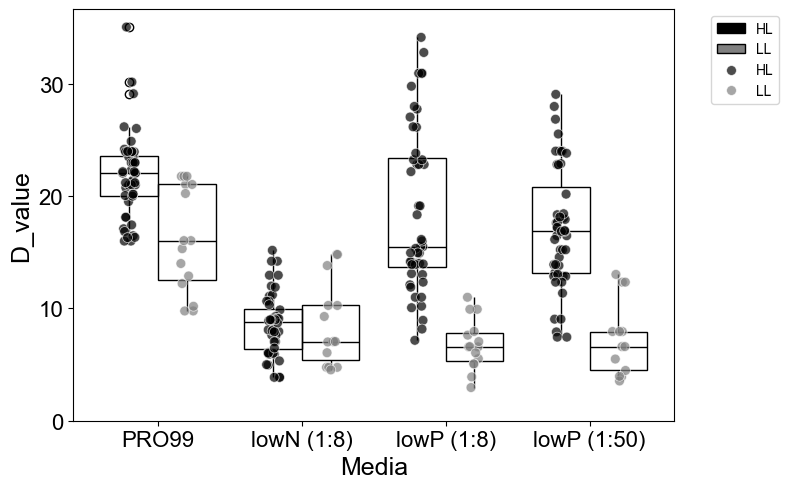

In [58]:
plt.figure(figsize=(8, 5))

# Define unique media and ecotypes
media_categories = traits_allgroups['media'].unique()
ecotype_categories = traits_allgroups['ecotype'].unique()


x_positions = {
    (media, ecotype): i + (j - len(ecotype_categories) / 2) * 0.2
    for i, media in enumerate(media_categories)
    for j, ecotype in enumerate(ecotype_categories)
}


traits_allgroups['x_jittered'] = traits_allgroups.apply(
    lambda row: (
        x_positions[(row['media'], row['ecotype'])]
        + np.random.uniform(-0.05, 0.05)
        + (0.2 if row['ecotype'] == 'LL' else 0) 
    ),
    axis=1
)


sns.boxplot(
    data=traits_allgroups,
    x='media',
    y='D_value',
    hue='ecotype',
    palette={'HL': 'black', 'LL': 'grey'},
    dodge=True, patch_artist=True,
    zorder=1, 
    showcaps=False,  # Remove caps
    boxprops={'facecolor': 'none', 'edgecolor': 'black'}, 
    whiskerprops={'color': 'black'}, 
    medianprops={'color': 'black'},  
)


sns.scatterplot(
    data=traits_allgroups,
    x='x_jittered',
    y='D_value',
    hue='ecotype', palette={'HL': 'black', 'LL': 'grey'},

    alpha=0.7,
    zorder=2,  
 s=50
)


plt.xlabel('Media', fontsize=18)
plt.ylabel('D_value', fontsize=18)

plt.xticks(
    ticks=np.arange(len(media_categories)),
    labels=media_categories, fontsize=16
)  # Custom tick labels
plt.yticks(fontsize=16)
plt.yticks(np.arange(0, 40, 10)) 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()


plt.show()



# Figure 2

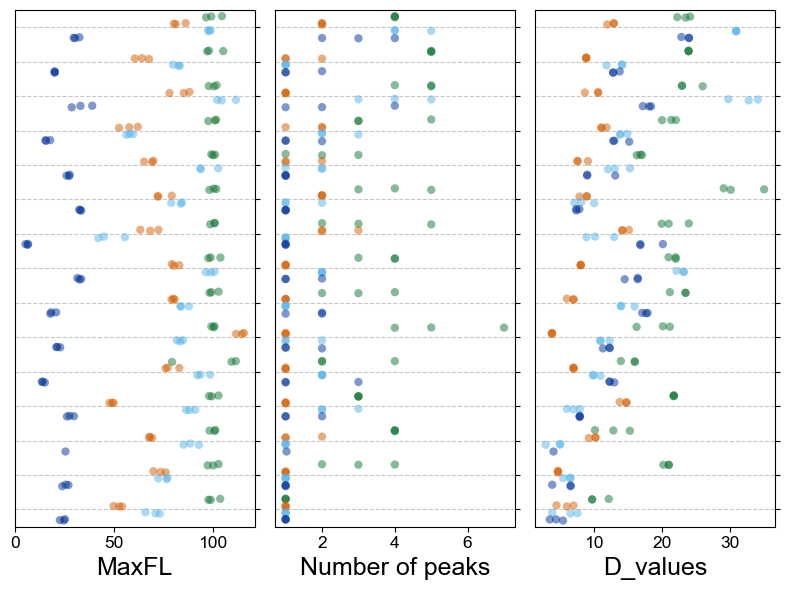

In [59]:
tubes_1_to_12 = [f"{letter}{i}" for letter in ['A', 'C', 'D'] for i in range(1, 13)]

tubes_13_to_24 = [f"{letter}{i}" for letter in ['A', 'C', 'D'] for i in range(13, 25)]

excluded_tubes = tubes_1_to_12 + tubes_13_to_24

filtered_traits = traits_allgroups[~traits_allgroups['number_of_tube'].isin(excluded_tubes)]


fig, axes = plt.subplots(1, 3, sharey=True, figsize=(8,6))  # 1 row, 3 columns


sns.stripplot(
    data=filtered_traits,  # Using the filtered data here
    x='norm_toPRO99', y='strain', hue='media', palette={'PRO99': '#117733', 'lowN (1:8)': '#D55E00', 'lowP (1:8)': '#56B4E9', 'lowP (1:50)': '#003399'},
    legend=False, size=6,
    dodge=True, alpha=0.5, jitter=0.1, ax=axes[0],  
    order=['MED4', 'MIT9515', 'MIT9202', 'MIT9215', 'MIT0604', 'MIT9301', 'SB', 'AS9601', 'MIT9312', 'MIT1314', 'NATL1A', 'NATL2A', 'PAC1', 'MIT9313', 'MIT1327'],
)
axes[0].set_xlabel("MaxFL", fontsize=18)
axes[0].set_ylabel("")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', color='black', labelsize=12.5)


sns.stripplot(
    data=filtered_traits,  # Using the filtered data here
    x='peak_count', y='strain', hue='media', palette={'PRO99': '#117733', 'lowN (1:8)': '#D55E00', 'lowP (1:8)': '#56B4E9', 'lowP (1:50)': '#003399'},
    order=['MED4', 'MIT9515', 'MIT9202', 'MIT9215', 'MIT0604', 'MIT9301', 'SB', 'AS9601', 'MIT9312', 'MIT1314', 'NATL1A', 'NATL2A', 'PAC1', 'MIT9313', 'MIT1327'],
    legend=False,size=6,
    dodge=True, alpha=0.5, jitter=0.1, ax=axes[1]  
)
axes[1].set_xlabel("Number of peaks", fontsize=18)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', color='black', labelsize=12.5)


sns.stripplot(
    data=filtered_traits,  # Using the filtered data here
    x='D_value', y='strain', hue='media', palette={'PRO99': '#117733', 'lowN (1:8)': '#D55E00', 'lowP (1:8)': '#56B4E9', 'lowP (1:50)': '#003399'},
    order=['MED4', 'MIT9515', 'MIT9202', 'MIT9215', 'MIT0604', 'MIT9301', 'SB', 'AS9601', 'MIT9312', 'MIT1314', 'NATL1A', 'NATL2A', 'PAC1', 'MIT9313', 'MIT1327'],
    legend=False,size=6,
    dodge=True, alpha=0.5, jitter=0.1, ax=axes[2]  
)
axes[2].set_xlabel("D_values", fontsize=18)
axes[2].set_ylabel("")  
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
axes[2].tick_params(axis='x', color='black', labelsize=12.5)


axes[2].yaxis.set_label_position('right')
axes[2].yaxis.tick_right()
axes[1].yaxis.tick_right()
axes[0].yaxis.tick_right()


axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation=0, fontsize=12)

# Adjust layout and display
plt.tight_layout()
plt.show()

# Supplementary SF4B

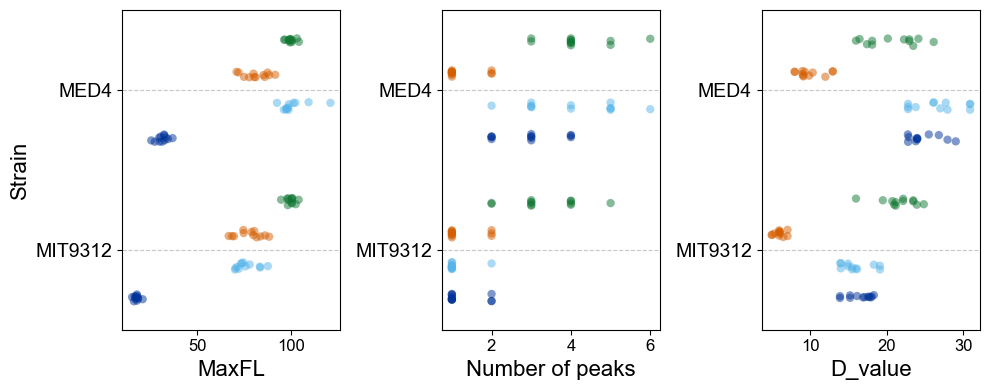

In [60]:
tubes_1_to_12 = [f"{letter}{i}" for letter in ['A', 'B', 'C', 'D'] for i in range(1, 13)]
tubes_13_to_24 = [f"{letter}{i}" for letter in ['A', 'B', 'C', 'D'] for i in range(13, 25)]
excluded_tubes = tubes_1_to_12 + tubes_13_to_24

filtered_traits_only = traits_allgroups[traits_allgroups['number_of_tube'].isin(excluded_tubes)]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))  

strain_order = ['MED4', 'MIT9312']
palette = {'PRO99': '#117733', 'lowN (1:8)': '#D55E00', 'lowP (1:8)': '#56B4E9', 'lowP (1:50)': '#003399'}


sns.stripplot(
    data=filtered_traits_only,  
    x='norm_toPRO99', y='strain', hue='media', palette=palette,
    legend=False, size=6,
    dodge=True, alpha=0.5, jitter=0.1, ax=axes[0],  
    order=strain_order,
)
axes[0].set_xlabel("MaxFL", fontsize=16)
axes[0].set_ylabel("Strain", fontsize=16)  # Y-axis title only here
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', color='black', labelsize=12)
axes[0].set_yticks(range(len(strain_order)))
axes[0].set_yticklabels(strain_order, fontsize=14)


sns.stripplot(
    data=filtered_traits_only,
    x='peak_count', y='strain', hue='media', palette=palette,
    order=strain_order,
    legend=False, size=6,
    dodge=True, alpha=0.5, jitter=0.1, ax=axes[1]  
)
axes[1].set_xlabel("Number of peaks", fontsize=16)
axes[1].set_ylabel("")  # No y-axis title
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', color='black', labelsize=12)
axes[1].set_yticks(range(len(strain_order)))
axes[1].set_yticklabels(strain_order, fontsize=14)


sns.stripplot(
    data=filtered_traits_only,
    x='D_value', y='strain', hue='media', palette=palette,
    order=strain_order, 
    legend=False, size=6,
    dodge=True, alpha=0.5, jitter=0.1, ax=axes[2]  
)
axes[2].set_xlabel("D_value", fontsize=16)
axes[2].set_ylabel("")  # No y-axis title
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
axes[2].tick_params(axis='x', color='black', labelsize=12)
axes[2].set_yticks(range(len(strain_order)))
axes[2].set_yticklabels(strain_order, fontsize=14)


plt.tight_layout()
plt.show()